<a href="https://colab.research.google.com/github/4rdnac/PCVK_Ganjil_2025/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import glob, os

 Mengubah tingkat kecerahan citra
----------------------------------
Masukkan nilai kecerahan: 30


/tmp/ipython-input-95892114.py:15: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


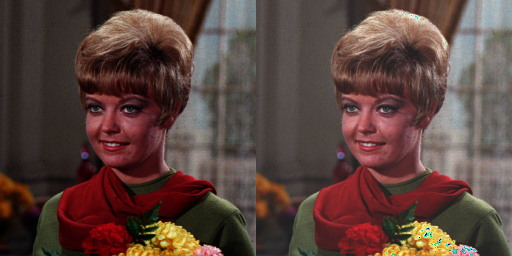

In [6]:
print(' Mengubah tingkat kecerahan citra')
print('----------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

original = cv. imread('/content/drive/MyDrive/PCVK/images/female.tiff')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for a in range(original. shape[2]):
      brightness_image[y,x,a] = np.clip(original[y,x,a] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

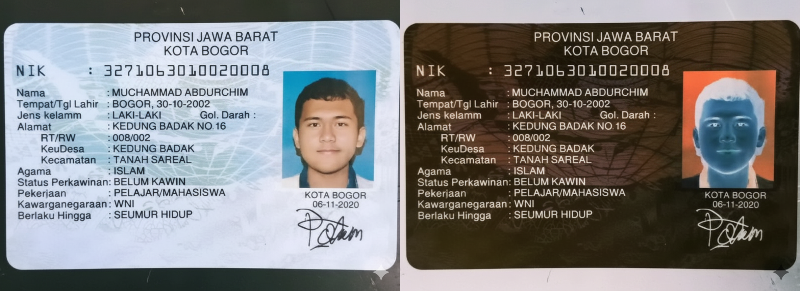

In [6]:
original = cv.imread('/content/drive/MyDrive/PCVK/images/KTP.png')

scale_width = 400
h, w = original.shape[:2]
new_h = int(h * (scale_width / w))
original = cv.resize(original, (scale_width, new_h))

# Inverse / negative
inverse = 255 - original

# Gabungkan dua gambar horizontal
final_frame = cv.hconcat([original, inverse])

# Tampilkan
cv2_imshow(final_frame)


 Mengubah tingkat kontras citra
----------------------------------
Masukkan nilai kecerahan [-255 - 255]: 30
Masukkan nilai kontras, mis. 1-3: 2


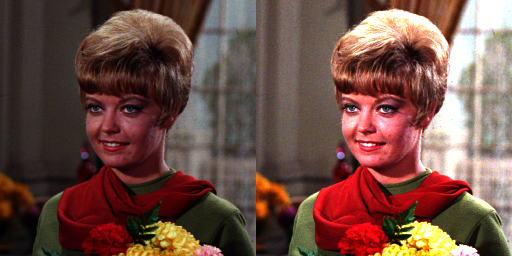

In [13]:
print(' Mengubah tingkat kontras citra')
print('----------------------------------')
try:
    a = int(input('Masukkan nilai kecerahan [-255 - 255]: '))
    b = float(input('Masukkan nilai kontras, mis. 1-3: '))

except ValueError:
    print('Error, input tidak valid')

# Baca gambar
original = cv.imread('/content/drive/MyDrive/PCVK/images/female.tiff')

# Siapkan array kosong
contrast_image = np.zeros(original.shape, original.dtype)

# Akses per piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for a in range(original.shape[2]):
            contrast_image[y, x, a] = np.clip(b * original[y, x, a] + a, 0, 255)

final_frame = cv.hconcat((original, contrast_image))
cv2_imshow(final_frame)


 Mengubah brightness dengan Transformasi Logaritmik
----------------------------------------------------
Masukkan nilai konstanta [-255 - 255]: 200


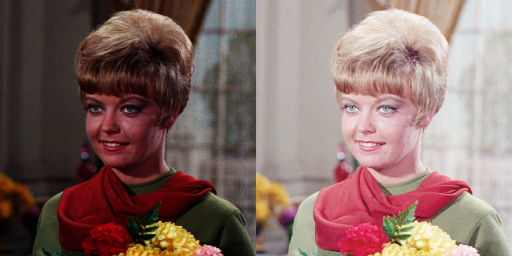

In [2]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Mengubah brightness dengan Transformasi Logaritmik')
print('----------------------------------------------------')
try:
    c = float(input('Masukkan nilai konstanta [-255 - 255]: '))
except ValueError:
    print('Error, input tidak valid')

# Baca gambar
original = cv.imread('/content/drive/MyDrive/PCVK/images/female.tiff')

# Konversi ke float supaya aman untuk log
img_float = original.astype(np.float32)

# Terapkan transformasi log
log_image = c * np.log1p(img_float)   # log(1+r)

# Normalisasi agar hasil tetap 0–255
log_image = (log_image / log_image.max()) * 255
log_image = log_image.astype(np.uint8)

# Gabungkan hasil sebelum & sesudah
final_frame = cv.hconcat((original, log_image))
cv2_imshow(final_frame)

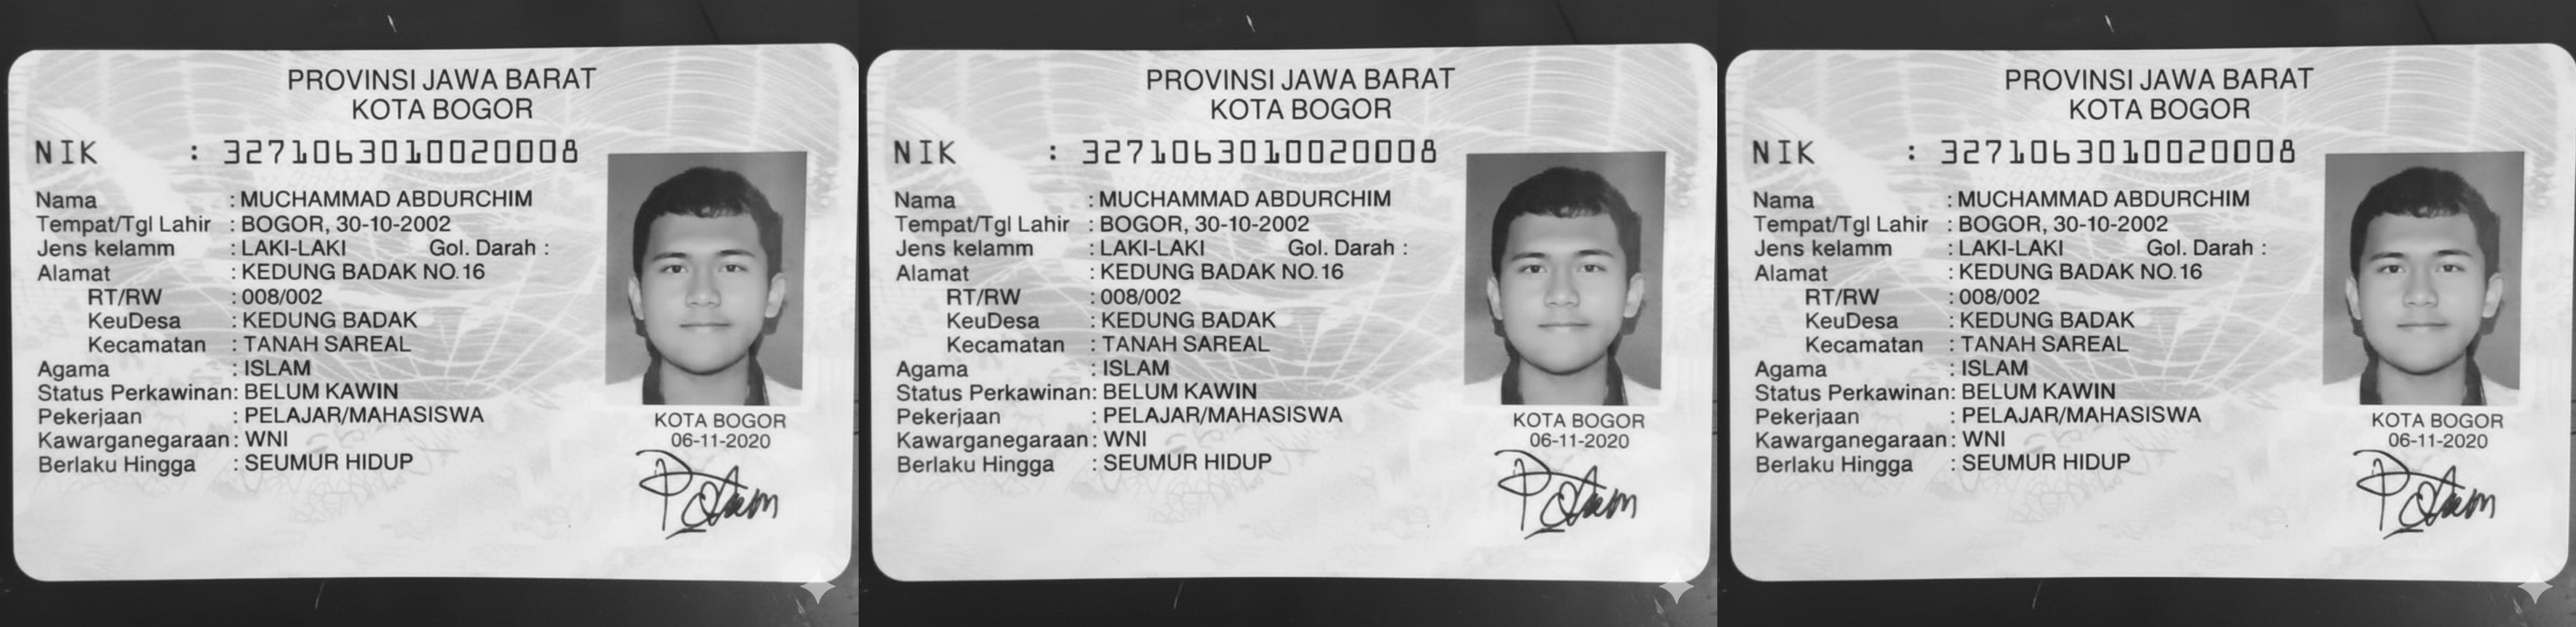

In [9]:
# Baca gambar
original = cv.imread('/content/drive/MyDrive/PCVK/images/KTP.png')

# Pisahkan channel BGR
B, G, R = cv.split(original)

# 1. Averaging
gray_avg = ((R.astype(np.float32) + G.astype(np.float32) + B.astype(np.float32)) / 3).astype(np.uint8)

# 2. Lightness
maxc = np.maximum(np.maximum(R, G), B)
minc = np.minimum(np.minimum(R, G), B)
gray_light = ((maxc.astype(np.float32) + minc.astype(np.float32)) / 2).astype(np.uint8)

# 3. Luminance (perceptual)
gray_lum = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

# Gabungkan hasil (horizontally)
final_frame = cv.hconcat([gray_avg, gray_light, gray_lum])
cv2_imshow(final_frame)


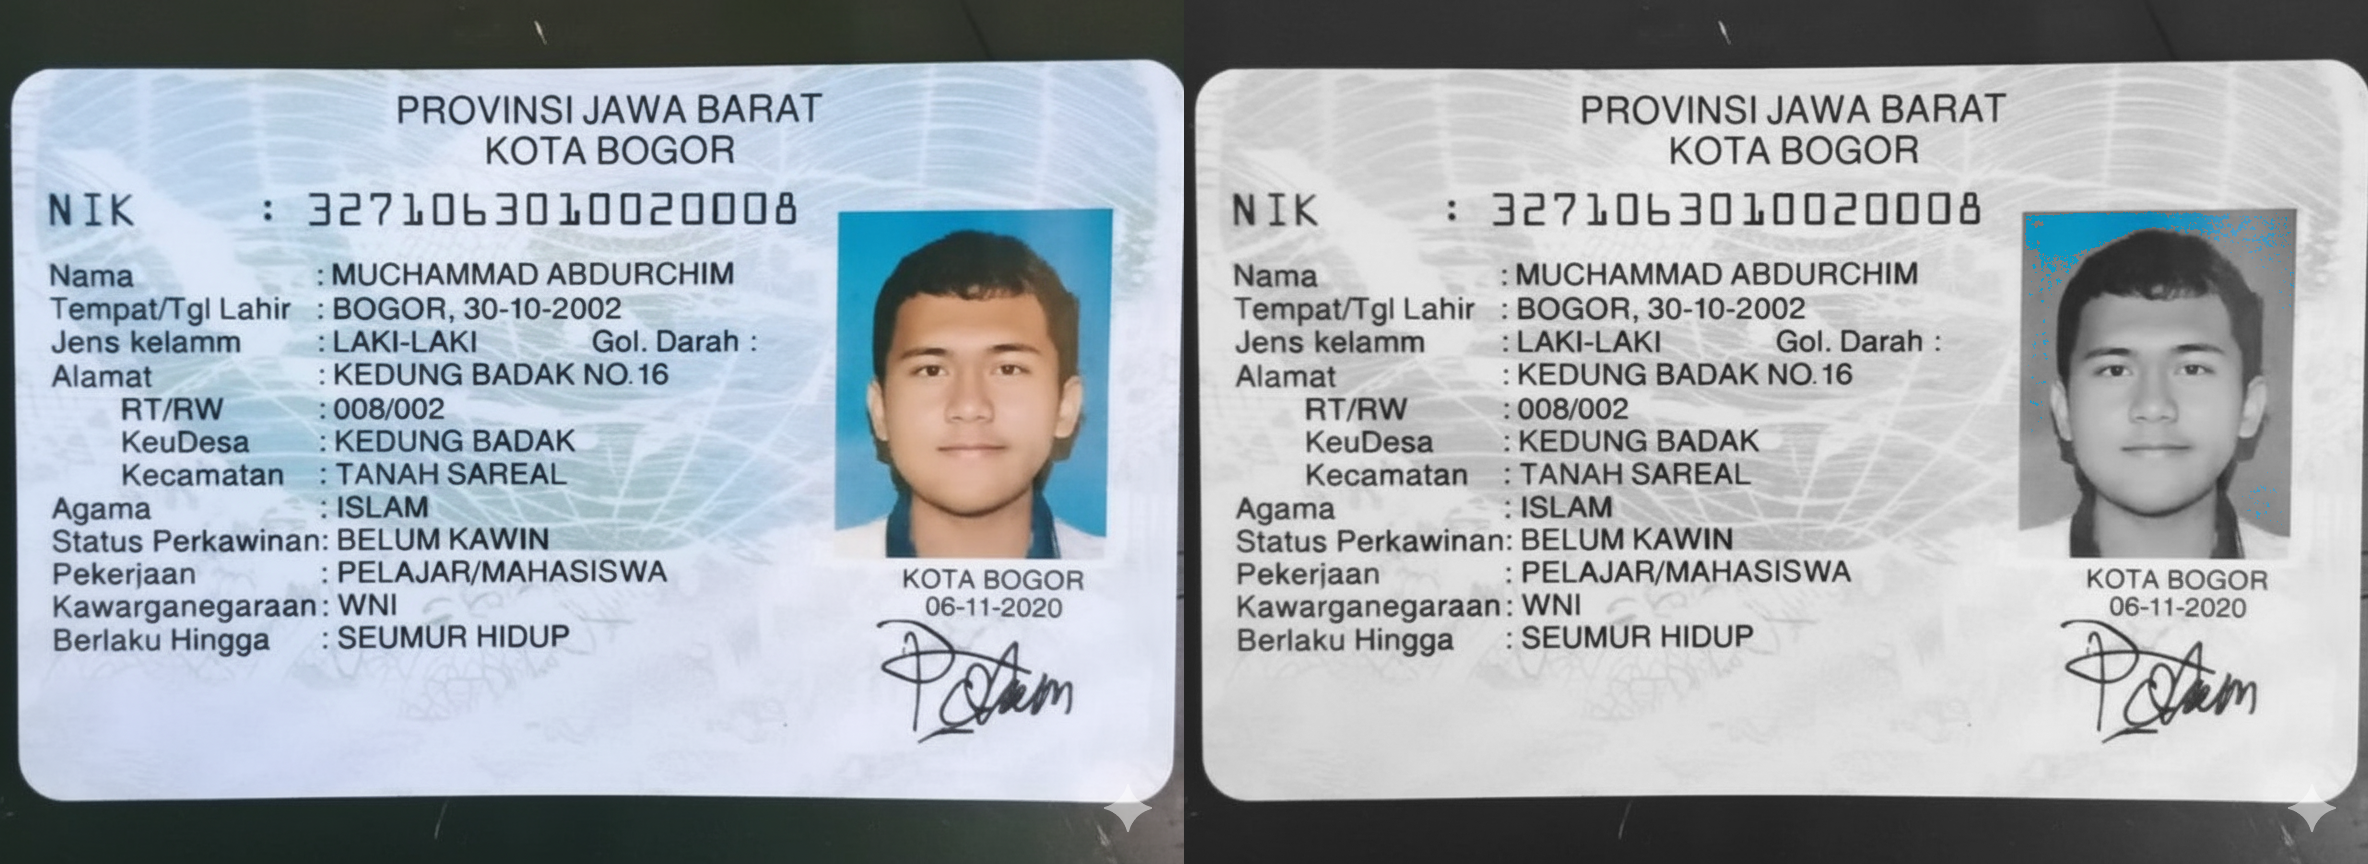

In [18]:
# Baca gambar
original = cv.imread('/content/drive/MyDrive/PCVK/images/KTP.png')

# Pisahkan channel BGR
B, G, R = cv.split(original)

# Ambang dominansi biru (tanpa input, langsung fix 40)
th = 40
mask_blue = (B.astype(np.int16) - R.astype(np.int16) > th) & \
            (B.astype(np.int16) - G.astype(np.int16) > th)

# Konversi bagian non-biru ke grayscale (luminance) dan pasang kembali
gray_lum = (0.21*R + 0.72*G + 0.07*B).astype(np.uint8)
color_pop = original.copy()
color_pop[~mask_blue] = cv.merge([gray_lum, gray_lum, gray_lum])[~mask_blue]

# Gabungkan Original + Hasil (berdampingan)
final_frame = cv.hconcat([original, color_pop])
cv2_imshow(final_frame)


 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 3


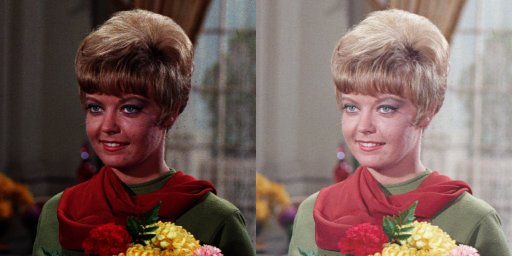

In [19]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')
    gamma = 1.0   # default kalau error

# Baca gambar
original = cv.imread('/content/drive/MyDrive/PCVK/images/female.tiff')

# Normalisasi ke 0..1
img_float = original.astype(np.float32) / 255.0

# Rumus gamma correction: I' = 255 * (I/255)^(1/gamma)
gamma_corrected = np.power(img_float, 1.0 / gamma)
gamma_corrected = (gamma_corrected * 255).astype(np.uint8)

# Gabungkan hasil sebelum & sesudah
final_frame = cv.hconcat([original, gamma_corrected])
cv2_imshow(final_frame)


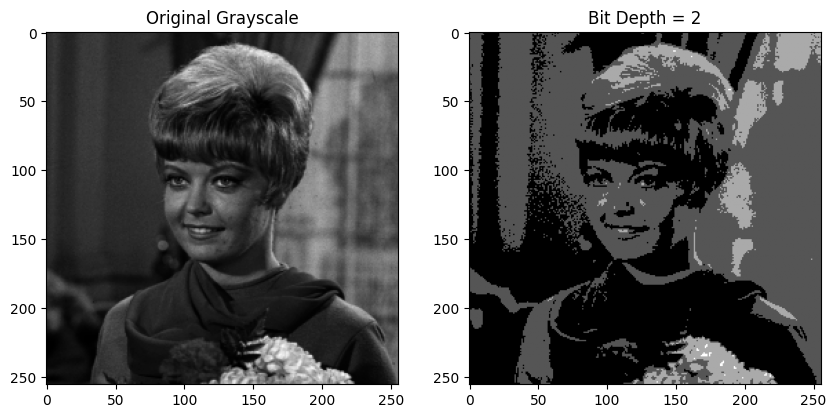

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Set bit depth
bit_depth = 2
level = 255 / (pow(2, bit_depth) - 1)

# Baca gambar dalam grayscale
original = cv.imread('/content/drive/MyDrive/PCVK/images/female.tiff', cv.IMREAD_GRAYSCALE)


# Proses quantization
quantized = np.round(original / level) * level
quantized = quantized.astype(np.uint8)

# Tampilkan pakai matplotlib
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original, cmap='gray')
plt.title('Original Grayscale')

plt.subplot(1,2,2)
plt.imshow(quantized, cmap='gray')
plt.title(f'Bit Depth = {bit_depth}')

plt.show()


Jumlah citra noise terbaca: 100


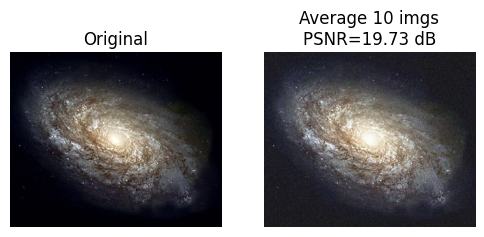

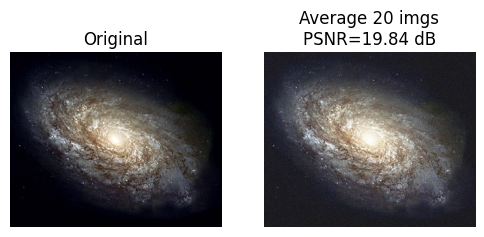

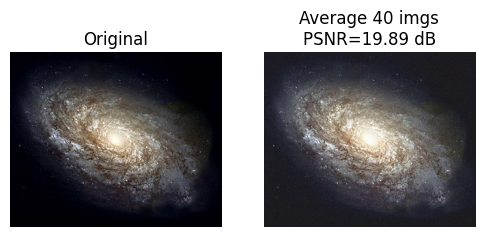

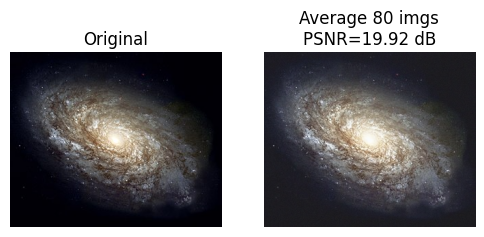

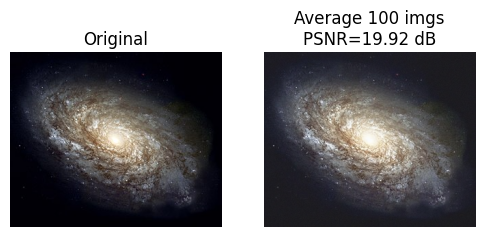

Tabel PSNR:
N gambar	PSNR (dB)
10		19.73
20		19.84
40		19.89
80		19.92
100		19.92


In [15]:
import cv2 as cv
import numpy as np
import glob
from math import log10, sqrt
import matplotlib.pyplot as plt

# Fungsi PSNR
def PSNR(img1, img2):
    mse = np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)
    if mse == 0:
        return 100
    return 20 * log10(255.0 / sqrt(mse))

# Baca citra asli
orig = cv.imread('/content/drive/MyDrive/PCVK/images/galaxy.jpg')

# Baca kumpulan noise images
cv_img = []
for img_path in glob.glob('/content/drive/MyDrive/PCVK/images/noises/*.jpg'):
    n = cv.imread(img_path)
    if n is not None:
        cv_img.append(n)

print(f"Jumlah citra noise terbaca: {len(cv_img)}")

# Fungsi average N gambar pertama
def average_first(n):
    stack = np.stack(cv_img[:n]).astype(np.float32)
    avg = np.mean(stack, axis=0)
    return np.clip(avg, 0, 255).astype(np.uint8)

# Uji dengan jumlah berbeda
counts = [10, 20, 40, 80, 100]
results = []

for c in counts:
    avg_img = average_first(c)
    p = PSNR(orig, avg_img)
    results.append((c, p))
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(cv.cvtColor(orig, cv.COLOR_BGR2RGB))
    plt.title('Original')
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(cv.cvtColor(avg_img, cv.COLOR_BGR2RGB))
    plt.title(f'Average {c} imgs\nPSNR={p:.2f} dB')
    plt.axis('off')
    plt.show()

# Cetak tabel PSNR
print("Tabel PSNR:")
print("N gambar\tPSNR (dB)")
for c, p in results:
    print(f"{c}\t\t{p:.2f}")
